In [1]:
import pygsheets # use 'pip install pygsheets'
import numpy
import datetime

import pandas
import geopandas
from geopandas.tools import overlay

pandas.set_option('display.max_rows', 100)

import shapely

# terminal data

## import

In [2]:
gc = pygsheets.authorize(service_account_env_var='GDRIVE_API_CREDENTIALS')
spreadsheet = gc.open_by_key('1tcS6Wd-Wp-LTDpLzFgJY_RSNDnbyubW3J_9HKIAys4A')

#spreadsheet[1] "Gas Pipelines" tab is the second index
terms_df_orig = spreadsheet.worksheet('title', 'Terminals').get_as_df()
terms_dict_df = spreadsheet.worksheet('title', 'Data dictionary').get_as_df()
terms_acronyms_df = spreadsheet.worksheet('title', 'Acronyms').get_as_df()
terms_copyright_df = spreadsheet.worksheet('title', 'Copyright').get_as_df()

## clean up

In [3]:
# remove oil export terminals
terms_df_orig = terms_df_orig[terms_df_orig['Type1']!='Oil']
# remove anything without a wiki page
terms_df_orig = terms_df_orig[terms_df_orig['Wiki']!='']

In [4]:
terms_dict_df_include = terms_dict_df.copy()[terms_dict_df.copy()['IncludeWithDataRelease']=='Yes']
terms_dict_df_include = terms_dict_df_include.sort_values('DataReleaseColumnOrder', ascending=True)
terms_dict_df_include = terms_dict_df_include[['VariableName','Definition']]

In [5]:
no_lonlat_options = [
    'Unknown',
    'TBD'
]

## clean up more, create shapely points

In [6]:
# code to create a dataframe with WKT formatted geometry

# (1) copy, clean up
to_convert_df = terms_df_orig.copy()
to_convert_df = to_convert_df[~(to_convert_df['Latitude'].isin(no_lonlat_options)) |
                             ~(to_convert_df['Longitude'].isin(no_lonlat_options))]

# also keep the non-converted ones separate
not_converted_df = terms_df_orig.copy()
not_converted_df = not_converted_df[(not_converted_df['Longitude'].isin(no_lonlat_options)) | 
                                    (not_converted_df['Latitude'].isin(no_lonlat_options))]
# add a dummy column so that the dimensions match with converted wkt pipelines
not_converted_df.assign(ColName='geometry')
not_converted_df['geometry'] = [shapely.geometry.Point()]*not_converted_df.shape[0]
not_converted_df.reset_index(drop=True)
not_converted_gdf = geopandas.GeoDataFrame(not_converted_df, geometry=not_converted_df['geometry'])

# (2) convert all terminals
terms_df_converted = to_convert_df.copy()
terms_df_converted.assign(ColName='geometry')
terms_df_converted['geometry'] = to_convert_df[['Longitude','Latitude']].apply(shapely.geometry.Point, axis=1)
terms_df_converted = terms_df_converted.reset_index(drop=True)

# # (3) store in a GeoDataFrame, attach a projection, transform to a different one
terms_df_gdf = geopandas.GeoDataFrame(terms_df_converted, geometry=terms_df_converted['geometry'])
terms_df_gdf = terms_df_gdf.set_crs('epsg:4326')
terms_df_gdf_4087 = terms_df_gdf.to_crs('epsg:4087')

/Users/baird/miniconda3/envs/gem/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)
/Users/baird/miniconda3/envs/gem/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


In [7]:
all_terms_df = pandas.concat([terms_df_gdf, not_converted_gdf])
all_terms_df = all_terms_df.reset_index(drop=True)
all_terms_df.sort_values('ComboID', inplace=True)

In [8]:
terms_dict_df_sorted = terms_dict_df[terms_dict_df['IncludeWithDataRelease']=='Yes'].sort_values('DataReleaseColumnOrder')
output_columns = terms_dict_df_sorted['VariableName'].tolist()

In [ ]:
all_terms_df_to_save = all_terms_df[output_columns]
all_terms_df_to_save_gdf = geopandas.GeoDataFrame(all_terms_df_to_save, geometry=all_terms_df['geometry'])

## get nat earth data

In [17]:
nat_earth_df = geopandas.read_file('/Users/baird/Dropbox/_gis-data/_natural_earth_data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp')

In [18]:
hk_geom = nat_earth_df.loc[nat_earth_df.ADMIN=='Hong Kong S.A.R.'].geometry.values[0]

In [19]:
macao_geom = nat_earth_df.loc[nat_earth_df.ADMIN=='Macao S.A.R'].geometry.values[0]

In [23]:
china_geom = nat_earth_df.loc[nat_earth_df.ADMIN=='China'].geometry.values[0]

In [24]:
for idx,row in all_terms_df_to_save_gdf.iterrows():
    if row['geometry'].within(china_geom):
        print(row)

TerminalID                                                         T0377
ProjectID                                                              0
ComboID                                                          T037700
Country                                                            China
Region                                                         East Asia
Wiki                   https://www.gem.wiki/Chaozhou_LNG_Terminal_(Hu...
Name                                     Chaozhou LNG Terminal (Huafeng)
OtherNames                                                    华丰潮州LNG储配站
Owner                              Sinoenergy (55%); Huafeng Group (45%)
Status                                                      Construction
StartYear1                                                          2021
StartYear2                                                              
StartYear3                                                              
StopYear                                           

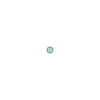

In [22]:
row['geometry'].within